<a href="https://colab.research.google.com/github/AARUSH-WALI/-DSA-CPP/blob/main/AudioAnalysisModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub librosa numpy pandas scikit-learn tqdm

In [2]:
import kagglehub

# RAVDESS dataset
ravdess_path = kagglehub.dataset_download(
    "uwrfkaggler/ravdess-emotional-speech-audio"
)

# Indian Accent dataset
indian_path = kagglehub.dataset_download(
    "polly42rose/indian-accent-dataset"
)

print("RAVDESS Path:", ravdess_path)
print("Indian Accent Path:", indian_path)


100%|██████████| 429M/429M [00:02<00:00, 178MB/s]

Extracting files...


100%|██████████| 3.92G/3.92G [00:35<00:00, 118MB/s]

Extracting files...


RAVDESS Path: /root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1
Indian Accent Path: /root/.cache/kagglehub/datasets/polly42rose/indian-accent-dataset/versions/3


In [3]:
emotion_to_confidence_class = {
    "neutral": 1,     # Neutral
    "calm": 2,        # Confident
    "happy": 2,       # Confident
    "surprised": 1,   # Neutral
    "angry": 0,       # Underconfident (unstable)
    "sad": 0,         # Underconfident
    "fearful": 0,     # Underconfident
    "disgust": 0      # Underconfident
}


In [4]:
import librosa
import numpy as np

def extract_features(audio_path):
    y, sr = librosa.load(audio_path, sr=16000, mono=True)
    y, _ = librosa.effects.trim(y)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    pitch = librosa.yin(y, fmin=75, fmax=300)
    energy = librosa.feature.rms(y=y)
    zcr = librosa.feature.zero_crossing_rate(y)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

    features = np.hstack([
        np.mean(mfcc, axis=1),
        np.std(mfcc, axis=1),
        np.nanmean(pitch),
        np.nanstd(pitch),
        np.mean(energy),
        np.std(energy),
        np.mean(zcr),
        np.mean(centroid)
    ])

    return features


In [5]:
X = []
y = []

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

import os
from tqdm import tqdm

for actor in os.listdir(ravdess_path):
    actor_path = os.path.join(ravdess_path, actor)
    if not os.path.isdir(actor_path):
        continue

    for file in os.listdir(actor_path):
        if file.endswith(".wav"):
            emotion_code = file.split("-")[2]
            emotion = emotion_map[emotion_code]

            label = emotion_to_confidence_class[emotion]

            audio_path = os.path.join(actor_path, file)
            features = extract_features(audio_path)

            X.append(features)
            y.append(label)


In [6]:
for root, _, files in os.walk(indian_path):
    for file in files:
        if file.endswith(".wav"):
            audio_path = os.path.join(root, file)
            features = extract_features(audio_path)

            X.append(features)
            y.append(1)  # Neutral

In [7]:
import numpy as np

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y distribution:", np.bincount(y))


X shape: (11975, 46)
y distribution: [  768 10823   384]


In [27]:
from sklearn.utils import resample
import numpy as np

# Split by class
X_under = X[y == 0]
y_under = y[y == 0]

X_neutral = X[y == 1]
y_neutral = y[y == 1]

X_conf = X[y == 2]
y_conf = y[y == 2]

# Downsample Neutral
X_neutral_down, y_neutral_down = resample(
    X_neutral,
    y_neutral,
    replace=False,
    n_samples=2000,   # IMPORTANT: cap neutral
    random_state=42
)

# Combine balanced data
X_bal = np.vstack([X_under, X_neutral_down, X_conf])
y_bal = np.hstack([y_under, y_neutral_down, y_conf])

print("Balanced distribution:", np.bincount(y_bal))


Balanced distribution: [ 768 2000  384]


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [29]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=300,
                       random_state=42)

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

preds = model.predict(X_test)

print(classification_report(y_test, preds, target_names=[
    "Underconfident", "Neutral", "Confident"
]))


                precision    recall  f1-score   support

Underconfident       0.65      0.82      0.73       153
       Neutral       0.98      0.98      0.98      2165
     Confident       0.69      0.43      0.53        77

      accuracy                           0.95      2395
     macro avg       0.77      0.74      0.75      2395
  weighted avg       0.95      0.95      0.95      2395



In [31]:
def predict_confidence(audio_path):
    feat = extract_features(audio_path).reshape(1, -1)
    pred = model.predict(feat)[0]

    mapping = {
        0: "Underconfident",
        1: "Neutral",
        2: "Confident"
    }

    return mapping[pred]


In [32]:
import numpy as np
print("Label distribution:", np.bincount(y))


Label distribution: [  768 10823   384]


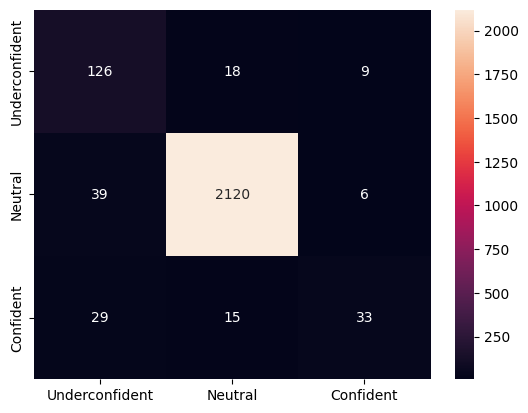

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Underconfident","Neutral","Confident"],
            yticklabels=["Underconfident","Neutral","Confident"])
plt.show()


In [34]:
from google.colab import files
files.upload()

{}

In [35]:
importances = model.feature_importances_

for i, val in enumerate(importances[:10]):
    print(f"Feature {i}: {val:.4f}")


Feature 0: 0.0563
Feature 1: 0.0659
Feature 2: 0.0404
Feature 3: 0.0320
Feature 4: 0.0154
Feature 5: 0.0153
Feature 6: 0.0149
Feature 7: 0.0338
Feature 8: 0.0095
Feature 9: 0.0142


In [36]:
import joblib
joblib.dump(model, "confidence_model.pkl")


['confidence_model.pkl']

In [37]:
joblib.dump({"feature_count": X.shape[1]}, "meta.pkl")


['meta.pkl']

In [38]:
#def confidence_pipeline(audio_path):
    #feat = extract_features(audio_path).reshape(1, -1)
    #return predict_confidence(audio_path)


In [39]:
import numpy as np
print("Balanced label distribution:", np.bincount(y_bal))


Balanced label distribution: [ 768 2000  384]


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_bal
)

model = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=400,
                       random_state=42)

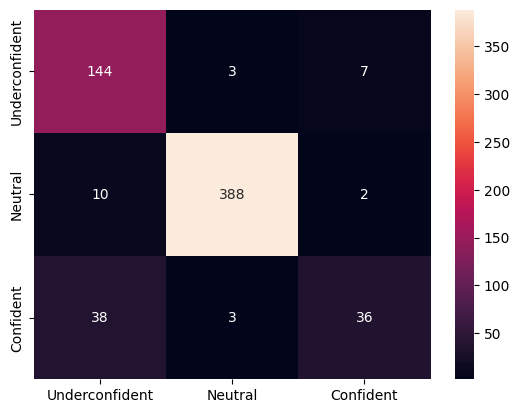

                precision    recall  f1-score   support

Underconfident       0.75      0.94      0.83       154
       Neutral       0.98      0.97      0.98       400
     Confident       0.80      0.47      0.59        77

      accuracy                           0.90       631
     macro avg       0.84      0.79      0.80       631
  weighted avg       0.90      0.90      0.89       631



In [41]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

preds = model.predict(X_test)

cm = confusion_matrix(y_test, preds)
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=["Underconfident","Neutral","Confident"],
    yticklabels=["Underconfident","Neutral","Confident"]
)
plt.show()

print(classification_report(
    y_test, preds,
    target_names=["Underconfident","Neutral","Confident"]
))


In [42]:
from google.colab import files
files.upload()


{}

In [43]:
predict_confidence("test.wav")


In [44]:
import joblib
joblib.dump(model, "confidence_model_rf.pkl")


['confidence_model_rf.pkl']

In [70]:
from IPython.display import Javascript, display
from google.colab import output
import base64

display(Javascript("""
async function recordAudio() {
  const stream = await navigator.mediaDevices.getUserMedia({ audio: true });
  const mediaRecorder = new MediaRecorder(stream);
  let chunks = [];

  mediaRecorder.ondataavailable = e => chunks.push(e.data);
  mediaRecorder.start();

  await new Promise(resolve => setTimeout(resolve, 5000)); // 5 seconds
  mediaRecorder.stop();

  return await new Promise(resolve => {
    mediaRecorder.onstop = () => {
      const blob = new Blob(chunks);
      const reader = new FileReader();
      reader.onloadend = () => resolve(reader.result);
      reader.readAsDataURL(blob);
    };
  });
}
"""))

audio_data = output.eval_js("recordAudio()")
print("Recording completed")


<IPython.core.display.Javascript object>

Recording completed


In [71]:
audio_bytes = base64.b64decode(audio_data.split(',')[1])

with open("live_audio.webm", "wb") as f:
    f.write(audio_bytes)

print("Saved as live_audio.webm")


Saved as live_audio.webm


In [72]:
!ffmpeg -y -i live_audio.webm -ar 16000 -ac 1 live_audio.wav


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [73]:
from IPython.display import Audio, display
display(Audio("live_audio.wav"))


In [74]:
import os
print(os.listdir())


['.config', 'live_audio.wav', 'live_audio.webm', 'meta.pkl', 'confidence_model_rf_final.pkl', 'confidence_model.pkl', 'confidence_model_rf.pkl', 'sample_data']


In [75]:
import joblib

joblib.dump(model, "confidence_model_rf_final.pkl")
print("Model saved successfully")


Model saved successfully


In [76]:
print(os.listdir())


['.config', 'live_audio.wav', 'live_audio.webm', 'meta.pkl', 'confidence_model_rf_final.pkl', 'confidence_model.pkl', 'confidence_model_rf.pkl', 'sample_data']


In [77]:
import librosa
import numpy as np
import joblib

model = joblib.load("confidence_model_rf_final.pkl")

def extract_features(audio_path):
    y, sr = librosa.load(audio_path, sr=16000, mono=True)
    y, _ = librosa.effects.trim(y)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    pitch = librosa.yin(y, fmin=75, fmax=300)
    energy = librosa.feature.rms(y=y)
    zcr = librosa.feature.zero_crossing_rate(y)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

    return np.hstack([
        np.mean(mfcc, axis=1),
        np.std(mfcc, axis=1),
        np.nanmean(pitch),
        np.nanstd(pitch),
        np.mean(energy),
        np.std(energy),
        np.mean(zcr),
        np.mean(centroid)
    ])

def predict_confidence_safe(audio_path):
    feat = extract_features(audio_path).reshape(1, -1)
    probs = model.predict_proba(feat)[0]

    labels = ["Underconfident", "Neutral", "Confident"]
    best_idx = np.argmax(probs)

    if probs[best_idx] < 0.55:
        return "Neutral (Low confidence)"

    return labels[best_idx]

print("Prediction:", predict_confidence_safe("live_audio.wav"))


Prediction: Neutral
